# Análise Exploratória

### Carregando a base de dados

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv('content/churn.csv')
dados.head()

,id_cliente,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,15634602,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0


In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           10000 non-null  int64  
 1   score_credito        10000 non-null  int64  
 2   pais                 10000 non-null  object 
 3   sexo_biologico       10000 non-null  object 
 4   idade                10000 non-null  int64  
 5   anos_de_cliente      10000 non-null  int64  
 6   saldo                10000 non-null  float64
 7   servicos_adquiridos  10000 non-null  int64  
 8   tem_cartao_credito   10000 non-null  int64  
 9   membro_ativo         10000 non-null  int64  
 10  salario_estimado     10000 non-null  float64
 11  churn                10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


Removeremos a coluna 'id_cliente', pois esse tipo de informação única para cada linha não é útil para uso em modelos de machine learning.

In [4]:
dados.drop(columns='id_cliente', inplace = True)

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   score_credito        10000 non-null  int64  
 1   pais                 10000 non-null  object 
 2   sexo_biologico       10000 non-null  object 
 3   idade                10000 non-null  int64  
 4   anos_de_cliente      10000 non-null  int64  
 5   saldo                10000 non-null  float64
 6   servicos_adquiridos  10000 non-null  int64  
 7   tem_cartao_credito   10000 non-null  int64  
 8   membro_ativo         10000 non-null  int64  
 9   salario_estimado     10000 non-null  float64
 10  churn                10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


## Variáveis Categóricas

In [6]:
dados.pais.unique()

array(['França', 'Espanha', 'Alemanha'], dtype=object)

In [7]:
dados.sexo_biologico.unique()

array(['Mulher', 'Homem'], dtype=object)

In [8]:
dados.tem_cartao_credito.unique()

array([1, 0], dtype=int64)

In [9]:
dados.membro_ativo.unique()

array([1, 0], dtype=int64)

In [10]:
import plotly.express as px

fig = px.histogram(dados, x='pais', color = 'churn',
                   barmode='group', text_auto=True,
                   title = 'Gráfico de comparação de churn por países dos clientes',
                   color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
                    })

fig.update_layout(
    xaxis_title='País',
    yaxis_title='Qtd Clientes',
    title_x = 0.075
)
fig.update_yaxes(showticklabels=False)

fig.show()

In [11]:
import plotly.express as px

fig = px.histogram(dados, x='sexo_biologico', color = 'churn',
                   barmode='group', text_auto=True,
                   title = 'Gráfico de comparação de churn por sexo biológico dos Clientes',
                   color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
                    })

fig.update_layout(
    xaxis_title='Sexo biológico',
    yaxis_title='Qtd Clientes',
    title_x = 0.075
)
fig.update_yaxes(showticklabels=False)

fig.show()

In [12]:
import plotly.express as px

fig = px.histogram(dados, x='tem_cartao_credito', color = 'churn',
                   barmode='group', text_auto=True,
                   title = ('Gráfico de comparação de Clientes'
                            '<br><span style="font-size:12px;">'
                           'Possuem ou não cartão de crédito, por Churn'
                           '<span>'),
                   color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
                    }, labels={
                        'churn': 'Churn',
                        1: 'Sim',
                        0: 'Não'
                    })

fig.update_layout(
    xaxis_title='Possui Cartão de Crédito',
    yaxis_title='Qtd Clientes',
    title_x = 0.077
)
fig.update_yaxes(showticklabels=False)
fig.update_xaxes(tickvals=[0, 1], ticktext=['Não', 'Sim'])

fig.for_each_trace(
    lambda t: t.update(
        name='Não' if t.name == '0' else 'Sim'
    )
)

fig.show()

In [13]:
display((1424/5631), (613/2332))

0.25288581069081867

0.26286449399656947

As porcentagens estão muito próximas, não parece haver relação

In [14]:
import plotly.express as px

fig = px.histogram(dados, x='membro_ativo', color = 'churn',
                   barmode='group', text_auto=True,
                   title = ('Gráfico de comparação de Clientes'
                            '<br><span style="font-size:12px;">'
                           'Possuem ou não Membro Ativo, por Churn'
                           '<span>'),
                   color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
                    }, labels={
                        'churn': 'Churn'
                    })

fig.update_layout(
    xaxis_title='Possui Membro Ativo',
    yaxis_title='Qtd Clientes',
    title_x = 0.077
)
fig.update_yaxes(showticklabels=False)
fig.update_xaxes(tickvals=[0, 1], ticktext=['Não', 'Sim'])

fig.for_each_trace(
    lambda t: t.update(
        name='Não' if t.name == '0' else 'Sim'
    )
)

fig.show()

In [15]:
display((1302/3547),(735/4416))

0.3670707640259374

0.16644021739130435

Aqui parece haver uma proporção bem diferente, então provavelmente é uma das variáveis que afeta a taxa de churn, sendo mais improvavel clientes que tem membro ativo darem churn.

## Variáveis Numéricas

In [16]:
fig = px.box(dados, x = 'score_credito', color = 'churn',
             title = 'Boxplot do Score de Crédito (Sem e Com Churn)',
             color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
             })
fig.update_layout(
    xaxis_title = 'Score de Crédito',
    legend_traceorder='reversed',
    title_x = 0.077
)
fig.show()

In [17]:
fig = px.violin(dados, y = 'idade', color = 'churn',
             title = 'Violinplot das Idades dos Clientes por Churn',
             color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
             }, box=True, category_orders={
                'churn': [0, 1]
              })
fig.update_layout(
    yaxis_title = 'Idade',
    title_x = 0.077
)
fig.show()

Notamos uma grande diferença. A primeiro momento aparenta que uma maior idade aumenta a chance de churn

In [18]:
fig = px.box(dados, x = 'anos_de_cliente', color = 'churn',
             title = 'Boxplot dos anos de cliente por Churn',
             color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
             })
fig.update_layout(
    xaxis_title = 'Anos de Cliente',
    legend_traceorder='reversed',
    title_x = 0.077
)
fig.show()

Mediana é a mesma pros dois tipos de cliente

In [19]:
fig = px.box(dados, x = 'saldo', color = 'churn',
             title = 'Boxplot do saldo dos clientes por Churn',
             color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
             })
fig.update_layout(
    xaxis_title = 'Saldo',
    legend_traceorder='reversed',
    title_x = 0.077
)
fig.show()

In [20]:
dados.saldo.describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: saldo, dtype: float64

Um pouco estranho não haver saldos negativos, talvez seja a natureza da empresa, mas também tem uma diferença em churn e não churn, por saldo.

In [21]:
fig = px.box(dados, x = 'servicos_adquiridos', color = 'churn',
             title = 'Boxplot da qtd de Serviços adquiridos pelos clientes por Churn',
             color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
             })
fig.update_layout(
    xaxis_title = 'Qtd. Serviços Adquiridos',
    legend_traceorder='reversed',
    title_x = 0.077
)
fig.show()

Não parece haver qualquer relação com churn a quantidade de serviços adquiridos.

In [22]:
dados.salario_estimado.describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: salario_estimado, dtype: float64

In [23]:
fig = px.box(dados, x = 'salario_estimado', color = 'churn',
             title = 'Boxplot de Salário estimado dos Clientes por Churn',
             color_discrete_map={
                     1: '#EF553B',
                     0: '#636EFA'
             })
fig.update_layout(
    xaxis_title = 'Salário Estimado',
    legend_traceorder='reversed',
    title_x = 0.077
)
fig.show()

Não parece haver grandes diferenças.

# Transformação de dados

## Variáveis explicativas e variável alvo

In [24]:
dados.head()

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0


In [25]:
x = dados.drop('churn', axis=1)
y = dados['churn']

In [26]:
x.head()

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10


In [27]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: churn, dtype: int64

## Transformando as variáveis explicativas

In [28]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [29]:
colunas = x.columns

In [30]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['pais', 'sexo_biologico']
), remainder = 'passthrough',
   sparse_threshold=0)

Tem cartão de crédito e membro ativo já estão certos, então não preciso passar.

In [31]:
x = one_hot.fit_transform(x)

In [32]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__pais_Alemanha', 'onehotencoder__pais_Espanha',
       'onehotencoder__pais_França',
       'onehotencoder__sexo_biologico_Mulher', 'remainder__score_credito',
       'remainder__idade', 'remainder__anos_de_cliente',
       'remainder__saldo', 'remainder__servicos_adquiridos',
       'remainder__tem_cartao_credito', 'remainder__membro_ativo',
       'remainder__salario_estimado'], dtype=object)

In [33]:
pd.DataFrame(x, columns=one_hot.get_feature_names_out(colunas))

,onehotencoder__pais_Alemanha,onehotencoder__pais_Espanha,onehotencoder__pais_França,onehotencoder__sexo_biologico_Mulher,remainder__score_credito,remainder__idade,remainder__anos_de_cliente,remainder__saldo,remainder__servicos_adquiridos,remainder__tem_cartao_credito,remainder__membro_ativo,remainder__salario_estimado
0,0.0,0.0,1.0,1.0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88
1,0.0,1.0,0.0,1.0,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58
2,0.0,0.0,1.0,1.0,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57
3,0.0,0.0,1.0,1.0,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63
4,0.0,1.0,0.0,1.0,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,1.0,0.0,771.0,39.0,5.0,0.00,2.0,1.0,0.0,96270.64
9996,0.0,0.0,1.0,0.0,516.0,35.0,10.0,57369.61,1.0,1.0,1.0,101699.77
9997,0.0,0.0,1.0,1.0,709.0,36.0,7.0,0.00,1.0,0.0,1.0,42085.58
9998,1.0,0.0,0.0,0.0,772.0,42.0,3.0,75075.31,2.0,1.0,0.0,92888.52


In [34]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: churn, dtype: int64

Não preciso usar LabelEncoder de sklearn.Preprocessing na variável alvo pois ela já está no formato correto, só farei por fins de prática e estudo.

In [35]:
from sklearn.preprocessing import LabelEncoder

In [36]:
label_encoder = LabelEncoder()

In [37]:
y = label_encoder.fit_transform(y)

In [38]:
y

array([1, 0, 1, ..., 1, 1, 0], dtype=int64)

# Divisão dos dados em Treino e Teste

Dividimos os dados para termos dados para comparação com o nosso modelo, para poder avaliar o quão bem esse modelo generaliza para novos dados, ou se está com problema de underfit/overfit.

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, stratify=y)

# Modelos de Classificação

## Modelo de base

É o modelo mais simples, ele utiliza um algoritmo que chuta todas as classificações para a classe que tem a maior frequência, servindo como critério de comparação para identificar se os outros modelos tem melhor desempenho que a classificação mais simples possível.

In [41]:
from sklearn.dummy import DummyClassifier

In [42]:
dummy = DummyClassifier()
dummy.fit(x_treino, y_treino)

dummy.score(x_teste, y_teste)

0.7964

Temos uma chance de acerto de quase 80% baseado nesses dados de treino e dados de teste.

## Árvore de decisão

É um modelo que se baseia em decisões simples tomadas pelo algoritmo, que separa os dados com base de menor e maior nos valores das features da base de dados, usa algo conhecido como índice de Gini para tomar decisões.

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
arvore = DecisionTreeClassifier()
arvore.fit(x_treino, y_treino)

DecisionTreeClassifier()

In [45]:
arvore.score(x_teste, y_teste)

0.8052

In [46]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__pais_Alemanha', 'onehotencoder__pais_Espanha',
       'onehotencoder__pais_França',
       'onehotencoder__sexo_biologico_Mulher', 'remainder__score_credito',
       'remainder__idade', 'remainder__anos_de_cliente',
       'remainder__saldo', 'remainder__servicos_adquiridos',
       'remainder__tem_cartao_credito', 'remainder__membro_ativo',
       'remainder__salario_estimado'], dtype=object)

In [47]:
list(dados.columns[0:-1])

['score_credito',
 'pais',
 'sexo_biologico',
 'idade',
 'anos_de_cliente',
 'saldo',
 'servicos_adquiridos',
 'tem_cartao_credito',
 'membro_ativo',
 'salario_estimado']

In [48]:
nome_colunas = ['Alemanha',
 'Espanha',
 'França',
 'Mulher',
 'Score Crédito',
 'Idade',
 'Anos de Cliente',
 'Saldo',
 'Servicos Adquiridos',
 'Tem Cartao de Crédito',
 'Membro Ativo',
 'Salario Estimado']

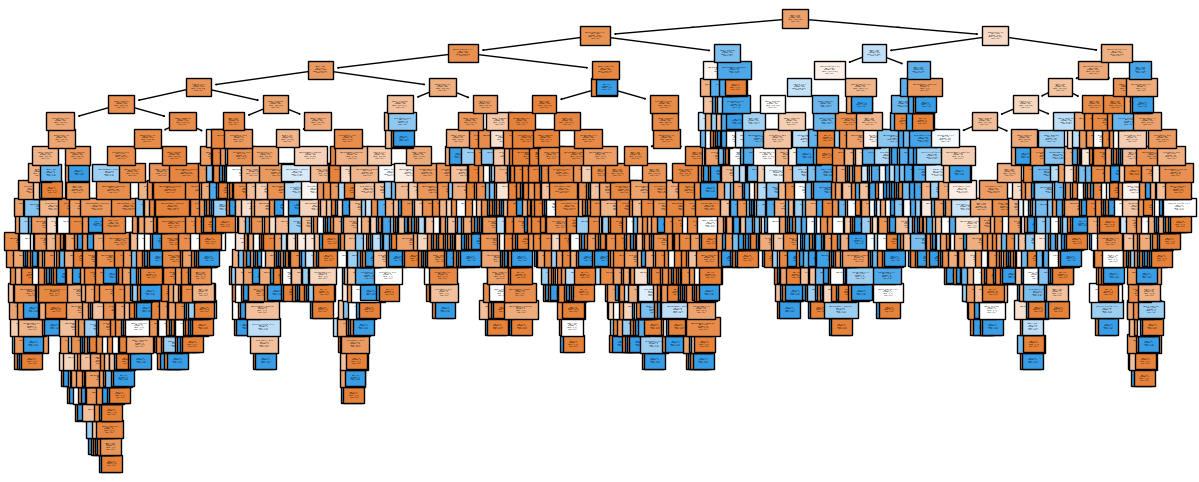

In [49]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plot_tree(arvore, filled=True, class_names=['Não', 'Sim'], fontsize=1, feature_names = nome_colunas);

In [50]:
arvore.score(x_treino, y_treino)

1.0

Aqui podemos ver que essa árvore de decisão só decorou os dados, considerando os ruidos dos dados como algo importante, ou seja overfit, agora limitaremos para 4 camadas de decisão.

In [51]:
arvore = DecisionTreeClassifier(max_depth = 4)
arvore.fit(x_treino, y_treino)

DecisionTreeClassifier(max_depth=4)

In [52]:
arvore.score(x_treino, y_treino)

0.8509333333333333

In [53]:
arvore.score(x_teste, y_teste)

0.854

Agora temos um modelo que tem 85% de precisão, bem melhor que o nosso modelo dummy.

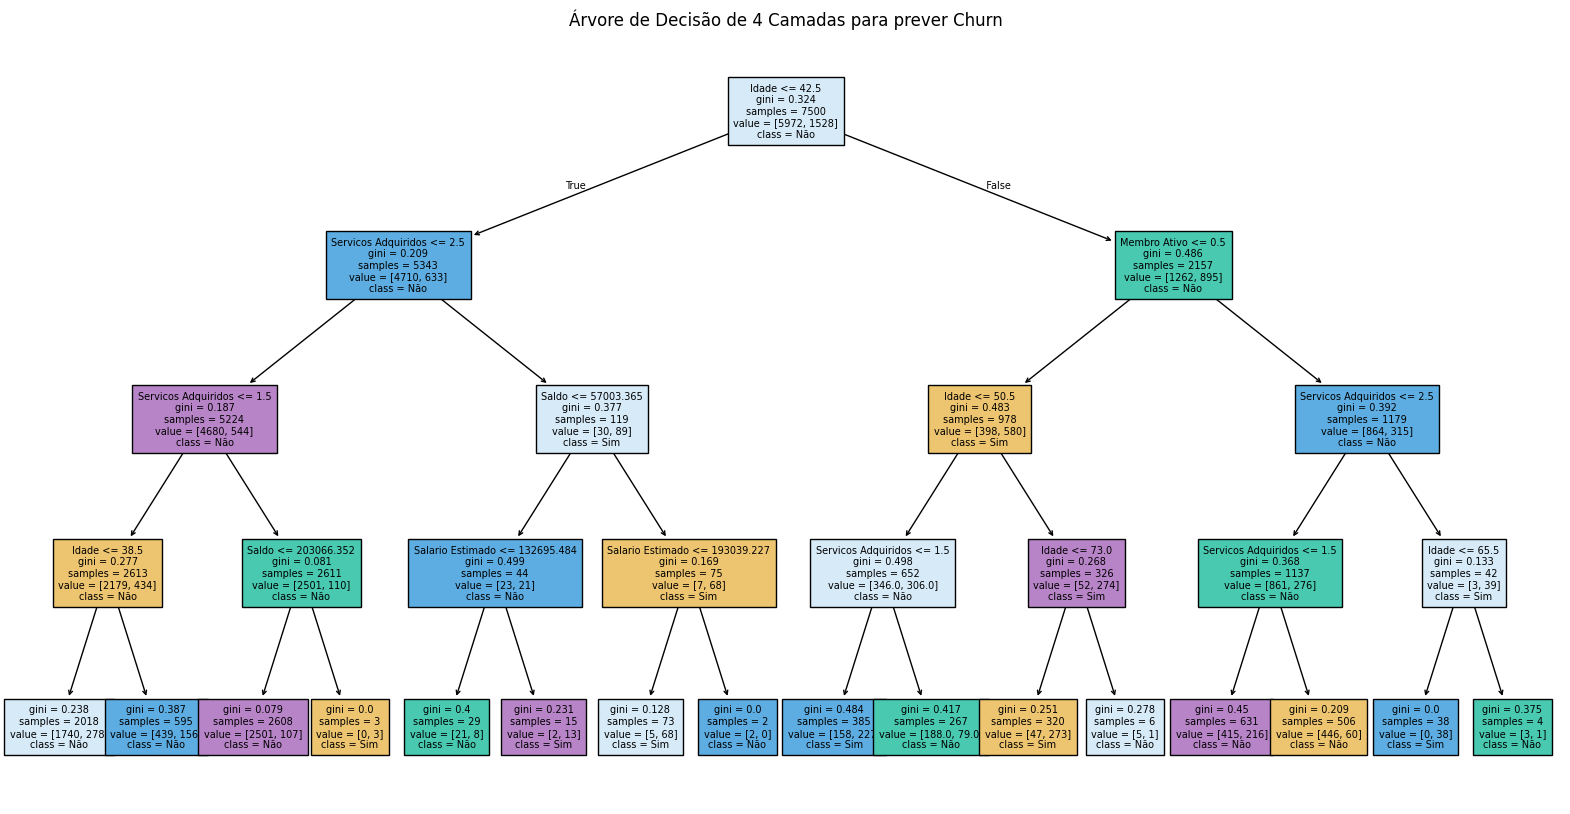

In [54]:
fig, ax = plt.subplots(figsize=(20,10))
plot_tree(arvore, filled=True, class_names=['Não', 'Sim'], fontsize=7, feature_names=nome_colunas, ax=ax);
plt.title('Árvore de Decisão de 4 Camadas para prever Churn')
cores = [
    '#D6EAF8',
    '#5DADE2',
    '#48C9B0',
    '#B784C7',
    '#EDC46F'
]

for i, text in enumerate(ax.texts):
    bbox = text.get_bbox_patch()

    if bbox:
        bbox.set_facecolor(cores[i % len(cores)])
        bbox.set_edgecolor('black')

plt.show()

Como haviamos explorado anteriormente nas análises dos dados numéricos, Idade possui um maior peso ao decidir a taxa de churn, então é escolhida como começo pela árvore de decisão.

# Normalização em preparação a KNN

In [55]:
from sklearn.preprocessing import MinMaxScaler

In [56]:
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(x_treino)

In [57]:
pd.DataFrame(x_treino_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.0,1.0,0.0,0.0,0.294,0.121622,0.7,0.595462,0.000000,0.0,0.0,0.837569
1,0.0,1.0,0.0,0.0,0.850,0.121622,0.4,0.000000,0.000000,1.0,1.0,0.203685
2,0.0,1.0,0.0,0.0,0.640,0.662162,0.6,0.632606,0.000000,1.0,1.0,0.592876
3,0.0,1.0,0.0,0.0,0.614,0.324324,0.5,0.165300,0.000000,1.0,0.0,0.564723
4,0.0,0.0,1.0,0.0,0.702,0.256757,0.8,0.429652,0.000000,1.0,0.0,0.084424
...,...,...,...,...,...,...,...,...,...,...,...,...
7495,1.0,0.0,0.0,1.0,0.666,0.283784,0.2,0.190059,0.333333,1.0,1.0,0.429857
7496,0.0,0.0,1.0,1.0,0.298,0.040541,0.3,0.703517,0.000000,1.0,1.0,0.769526
7497,1.0,0.0,0.0,0.0,0.456,0.216216,0.8,0.587837,0.333333,1.0,0.0,0.333116
7498,0.0,0.0,1.0,0.0,0.756,0.162162,1.0,0.457698,0.000000,0.0,1.0,0.187954


## KNN

O algoritmo KNN se baseia no cálculo de distância entre os registros da base de dados e busca elementos que estejam próximos uns dos outros (vizinhos) para tomar a decisão da classificação.

Por conta de usar cálculos de distância, esse algoritmo é influenciado pela escala das variáveis e por conta disso é necessário uma transformação nos dados antes de utilizar esse método.

In [58]:
from sklearn.neighbors import KNeighborsClassifier

In [59]:
knn = KNeighborsClassifier()

In [60]:
knn.fit(x_treino_normalizado, y_treino)

KNeighborsClassifier()

In [61]:
x_teste_normalizado = normalizacao.transform(x_teste)

In [62]:
knn.score(x_teste_normalizado, y_teste)

0.8196

Precisão de 82%

# Comparando e salvando o melhor modelo

In [63]:
print(f'Acurácia Dummy: {dummy.score(x_teste, y_teste)}')
print(f'Acurácia Árvore: {arvore.score(x_teste, y_teste)}')
print(f'Acurácia KNN: {knn.score(x_teste_normalizado, y_teste)}')

Acurácia Dummy: 0.7964
Acurácia Árvore: 0.854
Acurácia KNN: 0.8196


O modelo de árvore é o melhor, então ele será o escolhido para salvamento.

In [64]:
import pickle

In [ ]:
with open('content/modelo_onehotenc.pkl', 'wb') as arquivo:
  pickle.dump(one_hot, arquivo)

In [ ]:
with open('content/modelo_arvore.pkl', 'wb') as arquivo:
  pickle.dump(arvore, arquivo)

In [67]:
dados.head(1)

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,619,França,Mulher,42,2,0.0,1,1,1,101348.88,1


Agora faremos o teste do modelo em um novo dado.

In [68]:
novo_dado = pd.DataFrame({
    'score_credito': [850],
    'pais':['França'],
    'sexo_biologico':['Homem'],
    'idade': [27],
    'anos_de_cliente': [3],
    'saldo': [56000],
    'servicos_adquiridos': [1],
    'tem_cartao_credito': [1],
    'membro_ativo': [1],
    'salario_estimado': [85270.00]
})

In [69]:
novo_dado = pd.DataFrame(novo_dado)
novo_dado

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado
0,850,França,Homem,27,3,56000,1,1,1,85270.0


In [70]:
modelo_one_hot = pd.read_pickle('content/modelo_onehotenc.pkl')
modelo_arvore = pd.read_pickle('content/modelo_arvore.pkl')

In [71]:
novo_dado = modelo_one_hot.transform(novo_dado)
modelo_arvore.predict(novo_dado)

array([0], dtype=int64)

Segundo o nosso modelo, esse novo cliente não será churn.